In [21]:
!pip install demucs

In [22]:
from pathlib import Path
import torch
import librosa
import soundfile as sf
from demucs.pretrained import get_model
from demucs.apply import apply_model

In [23]:
# ---------- PATHS ----------
INPUT_PATH = Path("/content/data/input/good for the ghost - Alge.mp3")
OUTPUT_DIR = Path("/content/data/output_demucs_2")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"👉 Fichier d'entrée : {INPUT_PATH.resolve()}")
print(f"👉 Dossier de sortie : {OUTPUT_DIR.resolve()}")

# ---------- CHARGEMENT DU MODÈLE ----------
print("⏳ Chargement du modèle Demucs (htdemucs)...")
model = get_model("htdemucs")

# ---------- LECTURE DE L'AUDIO (librosa AU LIEU de torchaudio) ----------
print("⏳ Chargement de l'audio avec librosa...")
waveform, sr = librosa.load(str(INPUT_PATH), sr=None, mono=False)

# librosa retourne (time) ou (channels, time)
# → on force le format [channels, time]
import numpy as np
if waveform.ndim == 1:
    waveform = np.expand_dims(waveform, axis=0)

# Convertir en tenseur torch : [1, channels, time]
waveform = torch.tensor(waveform).float().unsqueeze(0)

# ---------- SÉPARATION ----------
print("🎧 Séparation en stems...")
sources = apply_model(model, waveform)[0] # [stems, channels, time]

# ---------- SAUVEGARDE avec soundfile ----------
for source_tensor, name in zip(sources, model.sources):
    out_path = OUTPUT_DIR / f"{INPUT_PATH.stem}_{name}.wav"
    sf.write(str(out_path),
             source_tensor.cpu().numpy().T,  # transpose → (time, channels)
             sr)
    print(f"✅ Stem '{name}' sauvegardé : {out_path.resolve()}")

👉 Fichier d'entrée : /content/data/input/good for the ghost - Alge.mp3
👉 Dossier de sortie : /content/data/output_demucs_2
⏳ Chargement du modèle Demucs (htdemucs)...
⏳ Chargement de l'audio avec librosa...
🎧 Séparation en stems...
✅ Stem 'drums' sauvegardé : /content/data/output_demucs_2/good for the ghost - Alge_drums.wav
✅ Stem 'bass' sauvegardé : /content/data/output_demucs_2/good for the ghost - Alge_bass.wav
✅ Stem 'other' sauvegardé : /content/data/output_demucs_2/good for the ghost - Alge_other.wav
✅ Stem 'vocals' sauvegardé : /content/data/output_demucs_2/good for the ghost - Alge_vocals.wav


In [24]:
!pip install musdb museval

In [25]:
import musdb

# Cela va télécharger ~800 Mo de données dans le dossier spécifié
mus = musdb.DB(root="data/musdb18_sample", subsets="test", download=True)

# Pour vérifier que ça fonctionne :
print(f"Nombre de pistes chargées : {len(mus)}")
track = mus[0]
print(f"Titre : {track.name}")

Nombre de pistes chargées : 50
Titre : AM Contra - Heart Peripheral


In [26]:
import musdb
import museval
import torch
import numpy as np
from demucs.pretrained import get_model
from demucs.apply import apply_model

# 1. Configuration
# 'subsets="test"' pour évaluer sur le set de test officiel
# 'download=True' si tu ne l'as pas encore sur ton disque
mus = musdb.DB(root="data/musdb18_sample", subsets="test", download=True)

# 2. Chargement du modèle Demucs
device = "cuda" if torch.cuda.is_available() else "cpu"
model = get_model("htdemucs")
model.to(device)
model.eval()

print(f"🚀 Début de l'évaluation sur {len(mus)} morceaux...")

for track in mus:
    print(f"🎧 Évaluation de : {track.name}")

    # Préparation de l'audio (Normalisation pour Demucs)
    # Shape attendue par Demucs : [1, channels, time]
    waveform = torch.from_numpy(track.audio.T).float().unsqueeze(0).to(device)

    with torch.no_grad():
        # Séparation
        sources = apply_model(model, waveform)[0]

    # 3. Préparation des dictionnaires pour museval
    # museval attend des dictionnaires : { 'nom_piste': numpy_array (samples, channels) }
    references = {
        'drums': track.targets['drums'].audio,
        'bass': track.targets['bass'].audio,
        'other': track.targets['other'].audio,
        'vocals': track.targets['vocals'].audio,
    }

    estimates = {}
    for i, name in enumerate(model.sources):
        # On repasse en (samples, channels) et cpu
        estimates[name] = sources[i].cpu().numpy().T

    # 4. Calcul des métriques
    # 'evaluate' compare les dictionnaires et calcule SDR, ISR, SIR, SAR
    scores = museval.eval_mus_track(track, estimates, output_dir="results")

    print(f"✅ Terminé pour {track.name}")
    print(scores)

# 5. Synthèse finale
# museval crée des fichiers .json dans le dossier 'results'

🚀 Début de l'évaluation sur 50 morceaux...
🎧 Évaluation de : AM Contra - Heart Peripheral
✅ Terminé pour AM Contra - Heart Peripheral
vocals          ==> SDR:  11.475  SIR:  15.546  ISR:  16.635  SAR:  12.903  
drums           ==> SDR:   7.812  SIR:  11.398  ISR:  12.891  SAR:   7.557  
bass            ==> SDR:   4.014  SIR:   4.064  ISR:  10.805  SAR:   7.226  
other           ==> SDR:   0.717  SIR:   1.354  ISR:   1.168  SAR:   0.652  

🎧 Évaluation de : Al James - Schoolboy Facination
✅ Terminé pour Al James - Schoolboy Facination
vocals          ==> SDR:   9.292  SIR:  14.125  ISR:  17.193  SAR:  10.754  
drums           ==> SDR:   6.365  SIR:   7.379  ISR:  10.729  SAR:   6.114  
bass            ==> SDR:  14.616  SIR:  23.066  ISR:  17.743  SAR:  16.339  
other           ==> SDR:   5.700  SIR:   9.719  ISR:   8.831  SAR:   5.674  

🎧 Évaluation de : Angels In Amplifiers - I'm Alright
✅ Terminé pour Angels In Amplifiers - I'm Alright
vocals          ==> SDR:  10.522  SIR:  16.956  

In [27]:
import numpy as np
import soundfile as sf
from pathlib import Path

def generate_test_stems(output_dir="data/test_synth"):
    path = Path(output_dir)
    path.mkdir(parents=True, exist_ok=True)

    sr = 44100
    duration = 100.0  # secondes
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    # 1. DRUMS : Des pulses toutes les 0.5s (Kick synthétique)
    drums = np.zeros_like(t)
    for i in range(0, len(t), int(sr * 0.5)):
        # Un petit burst de sinus décroissant pour simuler un impact
        end = min(i + int(sr * 0.1), len(t))
        drums[i:end] = np.sin(2 * np.pi * 60 * t[:end-i]) * np.exp(-10 * t[:end-i])

    # 2. BASS : Une onde sinusoïdale pure à 50Hz
    bass = 0.5 * np.sin(2 * np.pi * 50 * t)

    # 3. VOCALS : Une onde en dents de scie (timbre plus riche) à 440Hz
    from scipy import signal
    vocals = 0.3 * signal.sawtooth(2 * np.pi * 440 * t)

    # Sauvegarde des Stems (mono vers stéréo pour Demucs)
    stems = {'drums': drums, 'bass': bass, 'vocals': vocals}
    for name, data in stems.items():
        # Conversion en stéréo [time, channels]
        stereo = np.stack([data, data], axis=1)
        sf.write(path / f"{name}.wav", stereo, sr)

    # 4. MIX : La somme des trois
    mix = drums + bass + vocals
    # Normalisation pour éviter la saturation (clipping)
    mix = mix / np.max(np.abs(mix))
    sf.write(path / "mix_test.wav", np.stack([mix, mix], axis=1), sr)

    print(f"✅ Fichiers générés dans {path.resolve()}")

generate_test_stems()

✅ Fichiers générés dans /content/data/test_synth


In [28]:
# ---------- PATHS ----------
INPUT_PATH = Path("/content/data/test_synth/mix_test.wav")
OUTPUT_DIR = Path("/content/data/output_demucs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"👉 Fichier d'entrée : {INPUT_PATH.resolve()}")
print(f"👉 Dossier de sortie : {OUTPUT_DIR.resolve()}")

# ---------- CHARGEMENT DU MODÈLE ----------
print("⏳ Chargement du modèle Demucs (htdemucs)...")
model = get_model("htdemucs")

# ---------- LECTURE DE L'AUDIO (librosa AU LIEU de torchaudio) ----------
print("⏳ Chargement de l'audio avec librosa...")
waveform, sr = librosa.load(str(INPUT_PATH), sr=None, mono=False)

# librosa retourne (time) ou (channels, time)
# → on force le format [channels, time]
import numpy as np
if waveform.ndim == 1:
    waveform = np.expand_dims(waveform, axis=0)

# Convertir en tenseur torch : [1, channels, time]
waveform = torch.tensor(waveform).float().unsqueeze(0)

# ---------- SÉPARATION ----------
print("🎧 Séparation en stems...")
sources = apply_model(model, waveform)[0] # [stems, channels, time]

# ---------- SAUVEGARDE avec soundfile ----------
for source_tensor, name in zip(sources, model.sources):
    out_path = OUTPUT_DIR / f"{INPUT_PATH.stem}_{name}.wav"
    sf.write(str(out_path),
             source_tensor.cpu().numpy().T,  # transpose → (time, channels)
             sr)
    print(f"✅ Stem '{name}' sauvegardé : {out_path.resolve()}")

👉 Fichier d'entrée : /content/data/test_synth/mix_test.wav
👉 Dossier de sortie : /content/data/output_demucs
⏳ Chargement du modèle Demucs (htdemucs)...
⏳ Chargement de l'audio avec librosa...
🎧 Séparation en stems...
✅ Stem 'drums' sauvegardé : /content/data/output_demucs/mix_test_drums.wav
✅ Stem 'bass' sauvegardé : /content/data/output_demucs/mix_test_bass.wav
✅ Stem 'other' sauvegardé : /content/data/output_demucs/mix_test_other.wav
✅ Stem 'vocals' sauvegardé : /content/data/output_demucs/mix_test_vocals.wav


In [29]:
# Exemple de comparaison rapide pour la Basse
import museval

# Charger l'originale (ref) et la sortie de Demucs (est)
# Ils doivent avoir exactement la même taille (shape)
ref_bass = sf.read("data/test_synth/bass.wav")[0][:, :, np.newaxis]
est_bass = sf.read("data/output_demucs/mix_test_bass.wav")[0][:, :, np.newaxis]

# On transpose(dimension_source, dimension_samples, dimension_channels) pour avoir la même dimension que BSSeval
ref_bass_corrected = ref_bass.transpose(2, 0, 1)
est_bass_corrected = est_bass.transpose(2, 0, 1)

sdr, isr, sir, sar = museval.evaluate(ref_bass_corrected, est_bass_corrected)
print(f"SDR Synthétique Basse : {np.nanmedian(sdr):.2f} dB")

ref_drums = sf.read("data/test_synth/drums.wav")[0][:, :, np.newaxis]
est_drums = sf.read("data/output_demucs/mix_test_drums.wav")[0][:, :, np.newaxis]

# On transpose(dimension_source, dimension_samples, dimension_channels) pour avoir la même dimension que BSSeval
ref_drums_corrected = ref_drums.transpose(2, 0, 1)
est_drums_corrected = est_drums.transpose(2, 0, 1)

sdr, isr, sir, sar = museval.evaluate(ref_drums_corrected, est_drums_corrected)
print(f"SDR Synthétique Drums : {np.nanmedian(sdr):.2f} dB")

ref_vocals = sf.read("data/test_synth/vocals.wav")[0][:, :, np.newaxis]
est_vocals = sf.read("data/output_demucs/mix_test_vocals.wav")[0][:, :, np.newaxis]

# On transpose(dimension_source, dimension_samples, dimension_channels) pour avoir la même dimension que BSSeval
ref_vocals_corrected = ref_vocals.transpose(2, 0, 1)
est_vocals_corrected = est_vocals.transpose(2, 0, 1)

sdr, isr, sir, sar = museval.evaluate(ref_vocals_corrected, est_vocals_corrected)
print(f"SDR Synthétique Vocals : {np.nanmedian(sdr):.2f} dB")

SDR Synthétique Basse : 7.34 dB
SDR Synthétique Drums : 6.91 dB
SDR Synthétique Vocals : 0.01 dB


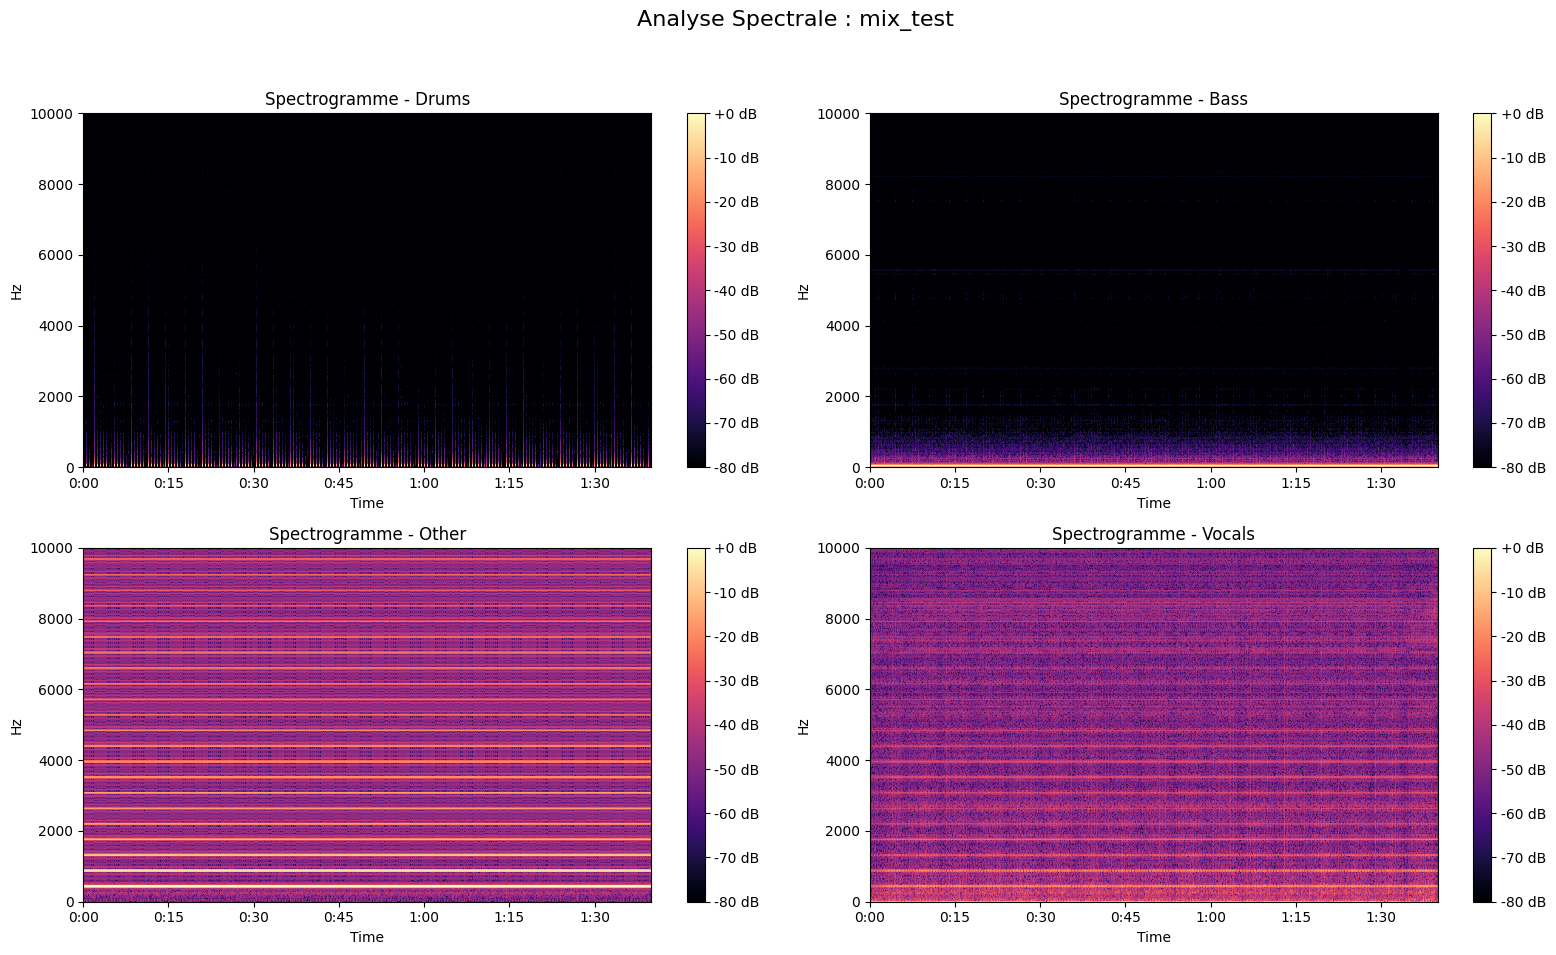

In [30]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_spectrograms(output_dir, song_name):
    # Liste des instruments standard de Demucs
    instruments = ['drums', 'bass', 'other', 'vocals']

    plt.figure(figsize=(16, 10))
    plt.suptitle(f"Analyse Spectrale : {song_name}", fontsize=16)

    for i, inst in enumerate(instruments):
        # Construction du chemin (adapte selon ton dossier de sortie)
        file_path = Path(output_dir) / f"{song_name}_{inst}.wav"

        if not file_path.exists():
            print(f"⚠️ Fichier introuvable : {file_path}")
            continue

        # 1. Chargement du signal
        y, sr = librosa.load(file_path, sr=None)

        # 2. Calcul de la STFT (Short-Time Fourier Transform)
        # On passe en décibels pour une meilleure visualisation
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

        # 3. Affichage
        plt.subplot(2, 2, i + 1)
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Spectrogramme - {inst.capitalize()}")
        plt.ylim(0, 10000)  # On limite à 10kHz pour mieux voir les détails musicaux

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Utilisation :
plot_spectrograms("data/output_demucs", "mix_test")

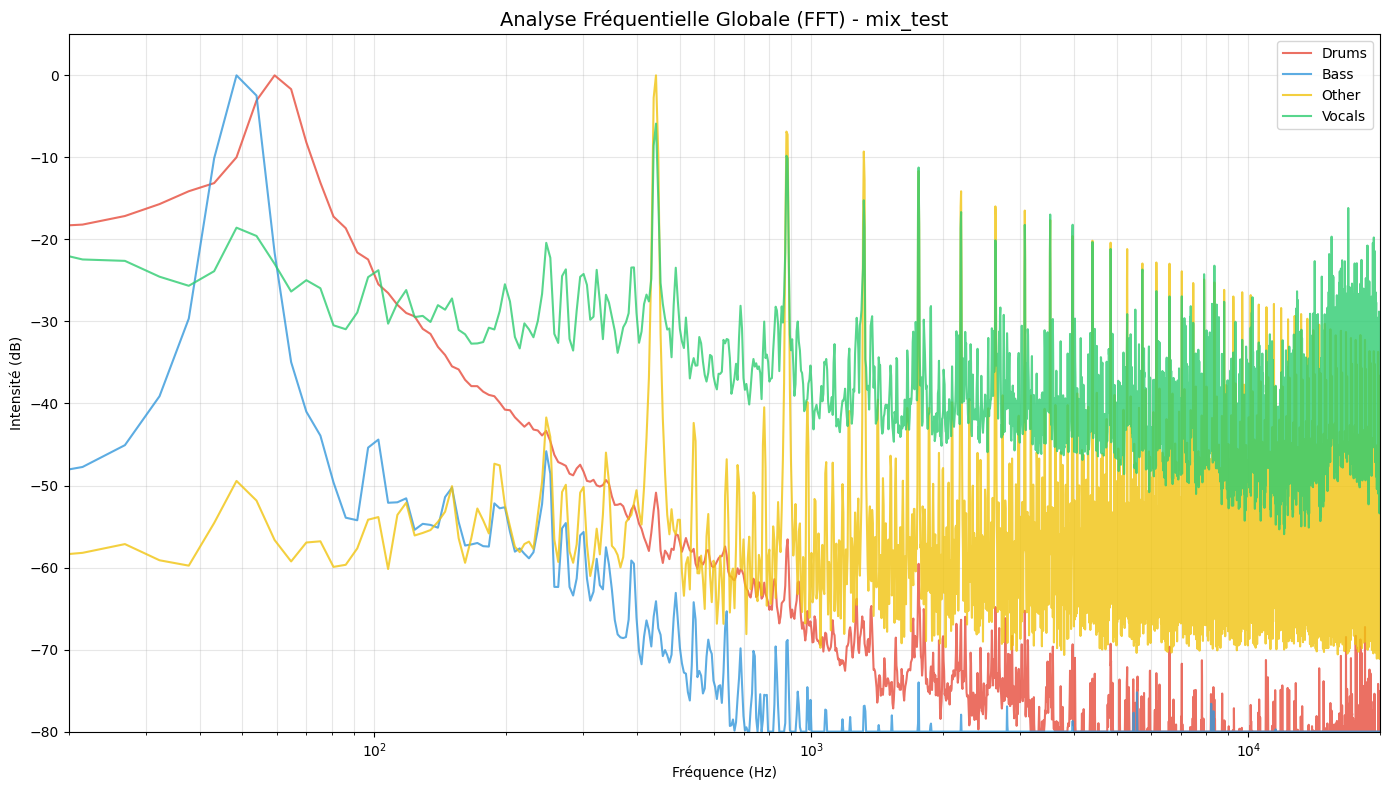

In [31]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_frequency_spectra(output_dir, song_name):
    instruments = ['drums', 'bass', 'other', 'vocals']
    colors = ['#e74c3c', '#3498db', '#f1c40f', '#2ecc71'] # Couleurs distinctes

    plt.figure(figsize=(14, 8))

    for i, inst in enumerate(instruments):
        file_path = Path(output_dir) / f"{song_name}_{inst}.wav"

        if not file_path.exists():
            continue

        # 1. Chargement du signal démixé
        y, sr = librosa.load(file_path, sr=None)

        # 2. Calcul de la FFT (Magnitude sur tout le morceau)
        # On utilise une grande fenêtre (n_fft) pour avoir la précision de ton image
        n_fft = 8192
        stft = np.abs(librosa.stft(y, n_fft=n_fft))

        # On fait la moyenne sur le temps pour avoir l'intensité globale
        mean_spectrum = np.mean(stft, axis=1)

        # Conversion en Décibels (dB)
        db_spectrum = librosa.amplitude_to_db(mean_spectrum, ref=np.max)

        # Fréquences correspondantes
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

        # 3. Affichage
        plt.plot(freqs, db_spectrum, label=inst.capitalize(), color=colors[i], alpha=0.8)

    # 4. Paramétrage pour coller à ton image
    plt.xscale('log')  # Échelle logarithmique (essentiel pour la musique)
    plt.title(f"Analyse Fréquentielle Globale (FFT) - {song_name}", fontsize=14)
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Intensité (dB)")
    plt.xlim(20, 20000)  # Spectre audible : 20Hz à 20kHz
    plt.ylim(-80, 5)     # Plage dynamique pour voir les pics et le bruit de fond
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Utilisation
plot_frequency_spectra("data/output_demucs", "mix_test")

In [32]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path

def plot_global_spectrum_comparison(ref_path, est_path, instrument_name):
    # 1. Chargement des fichiers
    y_ref, sr = librosa.load(ref_path, sr=None)
    y_est, _ = librosa.load(est_path, sr=None)

    # 2. Calcul de la Magnitude du Spectre (FFT)
    # On utilise une fenêtre assez grande (n_fft) pour avoir une bonne résolution
    n_fft = 4096

    # Calcul de la moyenne du spectre sur tout le signal
    spec_ref = np.abs(librosa.stft(y_ref, n_fft=n_fft))
    spec_ref_avg = np.mean(spec_ref, axis=1)

    spec_est = np.abs(librosa.stft(y_est, n_fft=n_fft))
    spec_est_avg = np.mean(spec_est, axis=1)

    # Passage en Décibels (dB)
    db_ref = librosa.amplitude_to_db(spec_ref_avg, ref=np.max)
    db_est = librosa.amplitude_to_db(spec_est_avg, ref=np.max)

    # Fréquences correspondantes
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # 3. Affichage
    plt.figure(figsize=(12, 6))

    # Courbe Originale vs Estimée
    plt.plot(freqs, db_ref, label="Référence (Original)", color='blue', alpha=0.6)
    plt.plot(freqs, db_est, label=f"Estimation Demucs ({instrument_name})", color='red', linestyle='--')

    # 4. Courbe de DIFFÉRENCE (L'erreur spectrale)
    # On affiche la différence absolue pour voir où l'IA s'éloigne du réel
    diff = np.abs(db_ref - db_est)
    plt.fill_between(freqs, -100, diff - 100, color='gray', alpha=0.2, label="Erreur (Différence)")

    plt.xscale('log') # Échelle logarithmique car l'audition humaine est log
    plt.title(f"Analyse du Spectre de Puissance : {instrument_name.capitalize()}")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Intensité (dB)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.xlim(20, 20000) # De 20Hz à 20kHz
    plt.ylim(-80, 5)    # Plage dynamique standard

    plt.show()

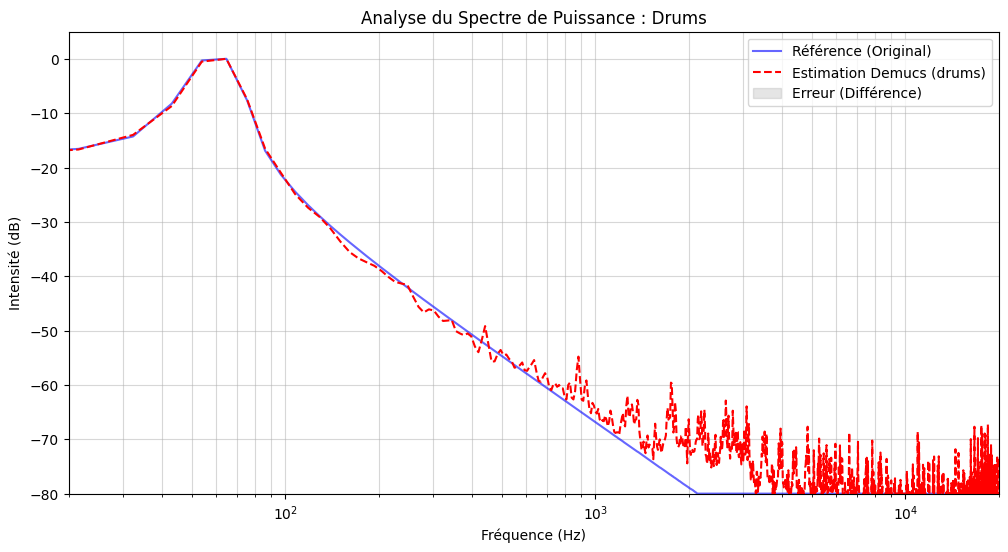

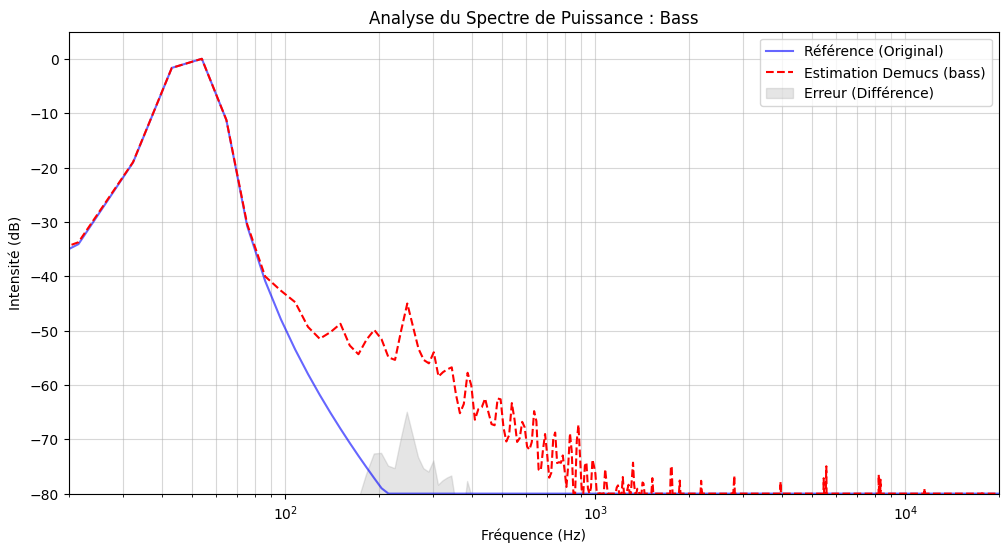

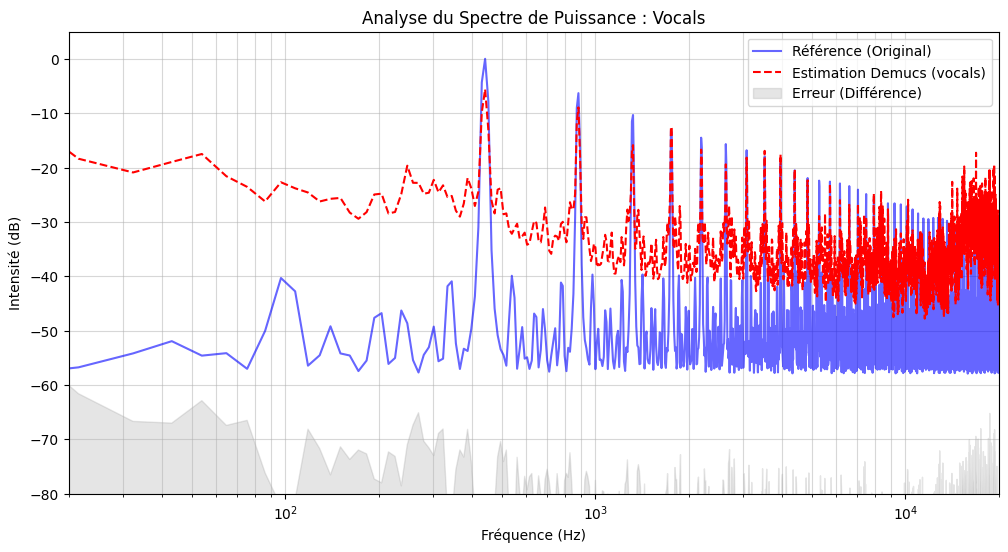

In [33]:
# Exemple d'utilisation :
instruments = ['drums', 'bass', 'vocals']
for i,inst in enumerate(instruments):
  plot_global_spectrum_comparison(f"data/test_synth/{inst}.wav", f"data/output_demucs/mix_test_{inst}.wav", inst)